In [47]:
!pip install thefuzz python-Levenshtein


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [48]:
#All relevant imports for the notebook
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import requests
import datetime
from datetime import datetime
import sqlite3
import numpy as np
from scipy import stats
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
from thefuzz import process
import geopandas as gpd
from shapely.geometry import Point


In [49]:
import pandas as pd
from pathlib import Path

# Use project-relative paths (works when cwd is project root; /src/ fails on Windows)
SRC = Path("src")
def _path(name):
    p = SRC / name
    if not p.exists() and "Arrests" in name and " (1)" not in name:
        alt = SRC / "NYPD_Arrests_Data__Historic_ (1).csv"
        return str(alt) if alt.exists() else str(p)
    return str(p)

airbnb_nyc_df = pd.read_csv(_path("AB_NYC_2019.csv"))
nypd_shooting_df = pd.read_csv(_path("NYPD_Shooting_Incident_Data__Historic_.csv"))
ny_tree_census_df = pd.read_csv(_path("new_york_tree_census_2015.csv"))
total_population_df = pd.read_csv(_path("Total Population.csv"), header=4)
arrest_data_df = pd.read_csv(_path("NYPD_Arrests_Data__Historic_.csv"))
nta_pop_df = pd.read_csv(_path("New_York_City_Population_By_Neighborhood_Tabulation_Areas.csv"))
nyc_gdf = gpd.read_file(_path("nycgeo.json"))
"""
display(ny_tree_census_df.head())
display(nypd_shooting_df.head())
display(airbnb_nyc_df.head())
display(Total_Population_df.head())
"""

'\ndisplay(ny_tree_census_df.head())\ndisplay(nypd_shooting_df.head())\ndisplay(airbnb_nyc_df.head())\ndisplay(Total_Population_df.head())\n'

#**Most impactful factors affecting Airbnb pricing in New York City**

**Hypothesis: Greenery, Reviews, Median Income, Distance to CBD and Crime Rate affect Airbnb prices**

As Airbnb grows in popularity across the world, getting an accurate estimate of the price of Airbnbs will help new Airbnb owners to better price their houses. We will explore the relationship between various factors of the Airbnb and its price. We believe that crime rate, greenery around the borough, median income of residents, proximity to the business district and the reviews of the Airbnb will have the greatest impact on its price.

#**Data source identification and exploration(Prepare)**

**Requirement analysis**: In order to estimate the price of Airbnbs, we have extracted various data points such as room type, number of reviews, availability, boroughs, along with the three factors in our hypothesis. We have selected three datasets which are connected by the 5 types of boroughs in New York City.

List of datasets:
- [New York City Airbnb Open Data (2019) ](https://www.kaggle.com/datasets/dgomonov/new-york-city-airbnb-open-data)
- [NYPD Arrest Data (2006-2019) ](https://www.kaggle.com/datasets/thaddeussegura/nypd-arrest-data-20062019)
- [New York City Shooting Incident Dataset](https://www.kaggle.com/datasets/thaddeussegura/new-york-city-shooting-dataset)
- [Tree Census in New York City](https://www.kaggle.com/datasets/nycparks/tree-census)
- [Total Population in New York City](https://data.cccnewyork.org/data/map/97/total-population#97/a/3/147/132/a/a)
- [Median Incomes](https://data.cccnewyork.org/data/map/66/median-incomes#66/39/3/107/131/a/a)

### DS1: New York City Airbnb Open Data(2019) kaggle

**Description:** The NYC Airbnb Open Data dataset, downloaded on 28/01/2026, contains detailed listing activity and metrics including geographical locations, prices, and room types across New York City. Specifically, it provides neighbourhood_group (the five boroughs) and neighbourhood data, which offer an ideal level of granularity for analyzing market density and local pricing trends. The dataset also includes the last_review date, allowing for temporal analysis of listing popularity and guest activity. 

In [50]:
# Display the shape of the dataset to understand the number of listings and attributes.
print("Shape of Airbnb dataset:", airbnb_nyc_df.shape)

Shape of Airbnb dataset: (48895, 16)


In [51]:
# Display column names to identify relevant attributes for analysis.
print("Columns in Airbnb dataset:")
print(airbnb_nyc_df.columns.tolist())

Columns in Airbnb dataset:
['id', 'name', 'host_id', 'host_name', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']


In [52]:
#We first take a look at the firsst 5 rows of the dataset
airbnb_nyc_df.head()


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [53]:
# Inspect the structure, data types, and non-null counts of the dataset.
airbnb_nyc_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

**Data Format & Granularity Assessment:**

Looking at this dataset, we observe that the price data is stored as numeric values (USD), while temporal information is captured in the `last_review` column in yyyy-mm-dd format, which requires standardization when merged with other datasets that may use different date conventions (e.g., MM/DD/YYYY in NYPD records). The geographical location is provided at the neighbourhood level (e.g., "Upper West Side", "Astoria"), offering sufficient spatial granularity for neighbourhood-level analysis and correlation with crime incidents and tree density. The room_type variable captures three distinct categories (Entire home/apt, Private room, Shared room), enabling us to control for property type effects on pricing. Critically, the dataset spans the entire New York City metropolitan area across all five boroughs—Manhattan, Brooklyn, Queens, The Bronx, and Staten Island—ensuring geographic diversity in our analysis. The `number_of_reviews`, `reviews_per_month`, and `availability_365` columns provide temporal engagement metrics that proxy for listing popularity and demand seasonality. However, to ensure robust cross-dataset comparisons, we must standardize date formats, validate coordinate precision (latitude/longitude), and account for potential listing volatility between the 2019 Airbnb snapshot and the 2015-2019 crime/arrest windows used in our analysis.

In [54]:
# creates a clean summary table of descriptive statistics for selected numeric columns in your Airbnb dataset.
description_df = airbnb_nyc_df[['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']].describe().round(1)
description_df = description_df.transpose()
description_df = description_df.rename(columns={
    'count': 'Number of Listings',
    'mean': 'Average Value',
    'std': 'Standard Deviation',
    'min': 'Minimum Value',
    '25%': '25th Percentile',
    '50%': 'Median Value',
    '75%': '75th Percentile',
    'max': 'Maximum Value'
})
display(description_df)

,Number of Listings,Average Value,Standard Deviation,Minimum Value,25th Percentile,Median Value,75th Percentile,Maximum Value
price,48895.0,152.7,240.2,0.0,69.0,106.0,175.0,10000.0
minimum_nights,48895.0,7.0,20.5,1.0,1.0,3.0,5.0,1250.0
number_of_reviews,48895.0,23.3,44.6,0.0,1.0,5.0,24.0,629.0
reviews_per_month,38843.0,1.4,1.7,0.0,0.2,0.7,2.0,58.5
calculated_host_listings_count,48895.0,7.1,33.0,1.0,1.0,1.0,2.0,327.0
availability_365,48895.0,112.8,131.6,0.0,0.0,45.0,227.0,365.0


In [55]:
# Check for total number of null values for each column

empty_records = airbnb_nyc_df.isnull().sum()
empty_records[empty_records > 0]

name                    16
host_name               21
last_review          10052
reviews_per_month    10052
dtype: int64

In [56]:
# Check for number of unique values in the 'neighbourhood' column
airbnb_nyc_df['neighbourhood'].nunique()

221

### Quality considerations

We summarize key quality aspects as follows:

For our task, the dataset provides sufficiently detailed listing-level information, including price, location coordinates, and neighbourhood identifiers, which are essential for our analysis. The dataset also offers broad coverage across New York City, making it suitable for neighbourhood-level aggregation. However, some attributes contain missing values, and inconsistencies in neighbourhood naming may require standardization during data preparation.

The cost of the dataset is ideal, as it is freely available on Kaggle and readily accessible for analysis.

### Conclusions for the Airbnb dataset

Overall, the Airbnb dataset is well-suited for our analytical goals, as it provides the primary variable of interest (listing price) together with relevant spatial and listing characteristics. Despite minor data quality issues such as missing values and naming inconsistencies, these can be addressed during data preparation. Therefore, we retain this dataset as the core data source for our project.

### DS2: New York City Shooting Incident(2019) kaggle

**Description:** The Kaggle dataset, focusing on historic shooting incidents, provides a detailed log of public safety events including the exact date, time, and geographic coordinates of each occurrence in 2019. More precisely, borough-level data, which offers the granularity that we require. This allows for the creation of "safety proximity" features that can significantly influence localized pricing models. The following code imports the data into a DataFrame and displays the first few rows, offering an initial look at the incident reports and their spatial attributes.

In [57]:
# check the first few rows of the NYPD shooting dataset to understand its structure and content.
nypd_shooting_df.head()

,INCIDENT_KEY,OCCUR_DATE,OCCUR_TIME,BORO,PRECINCT,JURISDICTION_CODE,LOCATION_DESC,STATISTICAL_MURDER_FLAG,PERP_AGE_GROUP,PERP_SEX,PERP_RACE,VIC_AGE_GROUP,VIC_SEX,VIC_RACE,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,Lon_Lat
0,74146165,08/14/2010,3:11:00,QUEENS,113,0.0,NaN,False,NaN,NaN,NaN,25-44,M,BLACK,1046573,183057,40.668915,-73.775341,POINT (-73.77534099699994 40.66891477200004)
1,66928846,10/17/2009,18:03:00,BROOKLYN,67,0.0,NaN,True,NaN,NaN,NaN,45-64,M,BLACK,1003313,176413,40.650877,-73.931302,POINT (-73.93130224699998 40.65087729100002)
2,29114164,05/18/2007,23:00:00,BROOKLYN,75,0.0,NaN,False,NaN,NaN,NaN,25-44,M,BLACK,1016292,176228,40.650332,-73.884529,POINT (-73.884529479 40.65033205800006)
3,85180336,06/09/2012,17:15:00,BROOKLYN,81,0.0,NaN,False,NaN,NaN,NaN,25-44,M,BLACK,1005597,188673,40.684523,-73.923032,POINT (-73.92303235699995 40.68452304300007)
4,73405770,06/27/2010,4:14:00,BRONX,47,0.0,NaN,False,NaN,NaN,NaN,25-44,M,BLACK,1023551,263366,40.889474,-73.857860,POINT (-73.85786021699995 40.88947350500007)


In [58]:
# Display column names to identify relevant attributes for analysis.
print("Columns in shooting dataset:")
print(nypd_shooting_df.columns.tolist())

Columns in shooting dataset:
['INCIDENT_KEY', 'OCCUR_DATE', 'OCCUR_TIME', 'BORO', 'PRECINCT', 'JURISDICTION_CODE', 'LOCATION_DESC', 'STATISTICAL_MURDER_FLAG', 'PERP_AGE_GROUP', 'PERP_SEX', 'PERP_RACE', 'VIC_AGE_GROUP', 'VIC_SEX', 'VIC_RACE', 'X_COORD_CD', 'Y_COORD_CD', 'Latitude', 'Longitude', 'Lon_Lat']


In [59]:
# Check the structure and data types of the NYPD shooting dataset
nypd_shooting_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21626 entries, 0 to 21625
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   INCIDENT_KEY             21626 non-null  int64  
 1   OCCUR_DATE               21626 non-null  str    
 2   OCCUR_TIME               21626 non-null  str    
 3   BORO                     21626 non-null  str    
 4   PRECINCT                 21626 non-null  int64  
 5   JURISDICTION_CODE        21624 non-null  float64
 6   LOCATION_DESC            9265 non-null   str    
 7   STATISTICAL_MURDER_FLAG  21626 non-null  bool   
 8   PERP_AGE_GROUP           14321 non-null  str    
 9   PERP_SEX                 14355 non-null  str    
 10  PERP_RACE                14355 non-null  str    
 11  VIC_AGE_GROUP            21626 non-null  str    
 12  VIC_SEX                  21626 non-null  str    
 13  VIC_RACE                 21626 non-null  str    
 14  X_COORD_CD               21626 no

In [60]:
# Check the number of missing values in each column.
print("Missing values per column:")
display(nypd_shooting_df.isna().sum().sort_values(ascending=False))

Missing values per column:


LOCATION_DESC              12361
PERP_AGE_GROUP              7305
PERP_SEX                    7271
PERP_RACE                   7271
JURISDICTION_CODE              2
INCIDENT_KEY                   0
OCCUR_DATE                     0
OCCUR_TIME                     0
PRECINCT                       0
BORO                           0
STATISTICAL_MURDER_FLAG        0
VIC_AGE_GROUP                  0
VIC_SEX                        0
VIC_RACE                       0
X_COORD_CD                     0
Y_COORD_CD                     0
Latitude                       0
Longitude                      0
Lon_Lat                        0
dtype: int64

In [61]:
# Analyze number of incidents per year to understand temporal distribution.
incident_years = pd.to_datetime(nypd_shooting_df['OCCUR_DATE'], errors='coerce').dt.year
display(incident_years.value_counts().sort_index())

OCCUR_DATE
2006    2055
2007    1887
2008    1958
2009    1828
2010    1910
2011    1939
2012    1717
2013    1339
2014    1464
2015    1434
2016    1208
2017     969
2018     951
2019     967
Name: count, dtype: int64

**Quality Considerations & Geographic Coverage Assessment:**

Examining the NYPD Shooting Incident dataset, we observe that the temporal scope (2015-2019) aligns well with our Airbnb pricing analysis window, and the geographic coverage spans all five boroughs of New York City, ensuring comprehensive spatial representation. However, several quality limitations merit consideration. First, the dataset exhibits inherent reporting bias—shooting incidents are only recorded when officially reported to NYPD, meaning unreported or under-reported incidents in certain neighbourhoods may distort our safety metrics. Second, the spatial granularity relies on incident coordinates that must be reverse-geocoded to neighbourhood boundaries, introducing potential mapping errors when incidents fall near neighbourhood borders or in areas with ambiguous geographic boundaries. Third, the dataset's completeness varies by borough; historically, certain precincts have demonstrated higher reporting consistency than others, which could artificially inflate or deflate neighbourhood-level safety rankings. Despite these limitations, the dataset remains valuable because: (1) it is freely available on Kaggle with no cost constraints, (2) it provides precise geospatial coordinates enabling neighbourhood-level aggregation, and (3) it represents the most comprehensive official crime incident record available for NYC during our target period. To mitigate data quality risks, we apply rigorous validation procedures including coordinate bounds checking, temporal filtering (2015-2019 only), and per-capita normalization using 2010 Census population data to control for neighbourhood size effects. We acknowledge that shooting incidents represent only one dimension of neighbourhood safety; arrest data (DS3) and median income (DS6) are used as complementary metrics to triangulate safety perceptions and reduce reliance on any single crime indicator.

### DS3:Total Population kaggle

**Description for Total Population Data:** The provided dataset, sourced from the U.S. Census Bureau, contains historic Total Population figures for New York City across various years, including our target year of 2019. The data is organized by Location, providing the borough-level granularity necessary to analyze market density and demand. This allows for a more nuanced understanding of Airbnb pricing by enabling us to calculate "per capita" metrics for crime or amenity availability. The following code imports the data into a DataFrame and displays the first few rows, showing the population counts and the specific community districts or neighborhoods covered.

In [62]:
# Load and clean Total Population CSV
total_population_df = pd.read_csv(str(Path("src") / "Total Population.csv"), header=4)
total_population_df.columns = total_population_df.iloc[0]  # Set row 0 as column names
total_population_df = total_population_df[1:].reset_index(drop=True)  # Remove row 0, reset index
total_population_df = total_population_df.rename(columns={
    'Location': 'Borough',
    'TimeFrame': 'Year',
    'Data': 'Population'
})
total_population_df['Year'] = pd.to_numeric(total_population_df['Year'])
total_population_df['Population'] = pd.to_numeric(total_population_df['Population'])

# Now display clean data
total_population_df.head()

,Borough,Year,DataFormat,Population,Fips
0,Battery Park/Tribeca,2005,Number,51150.45963,101
1,Greenwich Village,2005,Number,75508.54037,102
2,Lower East Side,2005,Number,145556.00000,103
3,Chelsea/Clinton,2005,Number,88754.39184,104
4,Midtown Business District,2005,Number,44420.60816,105


In [63]:
# Check the first few rows of the total population dataset
total_population_df.head()

,Borough,Year,DataFormat,Population,Fips
0,Battery Park/Tribeca,2005,Number,51150.45963,101
1,Greenwich Village,2005,Number,75508.54037,102
2,Lower East Side,2005,Number,145556.00000,103
3,Chelsea/Clinton,2005,Number,88754.39184,104
4,Midtown Business District,2005,Number,44420.60816,105


In [64]:
total_population_df.describe()

,Year,Population
count,3085.000000,3.085000e+03
mean,2014.322853,2.007877e+05
std,4.086628,7.129093e+05
min,2005.000000,0.000000e+00
25%,2012.000000,4.256000e+04
50%,2014.000000,9.294600e+04
75%,2017.000000,1.496740e+05
max,2024.000000,8.622698e+06


In [65]:
# Check the structure and data types of the total population dataset (after skipping metadata rows)
total_population_df[5:].info()

<class 'pandas.DataFrame'>
RangeIndex: 3080 entries, 5 to 3084
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Borough     3080 non-null   str    
 1   Year        3080 non-null   int64  
 2   DataFormat  3080 non-null   str    
 3   Population  3080 non-null   float64
 4   Fips        3080 non-null   str    
dtypes: float64(1), int64(1), str(3)
memory usage: 120.4 KB


### DS4: NYPD Arrest Data

**Description for NYPD Arrest Data:** The Kaggle dataset, encompassing historic NYPD arrest records from 2006 to 2024, provides a comprehensive record of every arrest effected in New York City. This dataset includes highly specific geospatial coordinates and other markers such as date and time, which are vital for a long-term analysis of neighborhood safety evolution. More precisely, it contains the borough and precinct, which are at the exact level of granularity required. For our Airbnb smart pricing project, this allows us to track how the safety profile of a specific borough and its market value—has shifted over nearly two decades. The following code imports the data into a DataFrame and displays the first few rows, highlighting the offense categories and location descriptors used in our predictive model.


In [66]:
# Check first few rows of the arrest data
arrest_data_df.head()

,ARREST_KEY,ARREST_DATE,PD_CD,PD_DESC,KY_CD,OFNS_DESC,LAW_CODE,LAW_CAT_CD,ARREST_BORO,ARREST_PRECINCT,JURISDICTION_CODE,AGE_GROUP,PERP_SEX,PERP_RACE,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,Lon_Lat
0,10837169,04/02/2006,NaN,NaN,NaN,NaN,NaN,NaN,Q,101,0.0,NaN,M,BLACK,1051775.0,159727.0,40.604841,-73.756823,POINT (-73.75682250899997 40.604840985000074)
1,189797412,11/09/2018,475.0,NaN,NaN,NaN,PL 1651601,M,M,28,1.0,25-44,F,WHITE HISPANIC,997374.0,234664.0,40.810773,-73.952592,POINT (-73.95259158999993 40.81077276700007)
2,189992103,11/14/2018,475.0,NaN,NaN,NaN,PL 1651601,M,K,75,1.0,18-24,M,BLACK,1021568.0,185710.0,40.676337,-73.865464,POINT (-73.86546353999995 40.676337363000066)
3,189714430,11/07/2018,117.0,RECKLESS ENDANGERMENT 1,126.0,MISCELLANEOUS PENAL LAW,PL 1202500,F,M,26,0.0,45-64,M,WHITE,993685.0,233346.0,40.807160,-73.965920,POINT (-73.96591978699998 40.80715993100006)
4,190067816,11/15/2018,586.0,NaN,NaN,NaN,PL 230341A,F,M,5,0.0,18-24,M,BLACK,984946.0,200203.0,40.716196,-73.997491,POINT (-73.99749074599998 40.716195914000025)


In [67]:
# Generate descriptive statistics for the arrest data
arrest_data_df.describe()

,ARREST_KEY,PD_CD,KY_CD,ARREST_PRECINCT,JURISDICTION_CODE,X_COORD_CD,Y_COORD_CD,Latitude,Longitude
count,5.012956e+06,5.012695e+06,5.003927e+06,5.012956e+06,5.012946e+06,5.012955e+06,5.012955e+06,5.012955e+06,5.012955e+06
mean,9.579149e+07,5.117004e+02,3.016261e+02,6.062439e+01,1.304714e+00,1.005357e+06,2.149659e+05,4.075649e+01,-7.392378e+01
std,5.222361e+07,2.633719e+02,1.817349e+02,3.430862e+01,9.427788e+00,1.999599e+04,1.648721e+05,4.456872e-01,7.216800e-02
min,9.926901e+06,0.000000e+00,1.010000e+02,1.000000e+00,0.000000e+00,9.133570e+05,1.211310e+05,4.049891e+01,-7.425494e+01
25%,5.931854e+07,2.930000e+02,1.260000e+02,3.300000e+01,0.000000e+00,9.933700e+05,1.868860e+05,4.067957e+01,-7.396707e+01
50%,8.345894e+07,5.110000e+02,3.410000e+02,6.000000e+01,0.000000e+00,1.004890e+06,2.094910e+05,4.074166e+01,-7.392549e+01
75%,1.435467e+08,7.500000e+02,3.480000e+02,8.400000e+01,0.000000e+00,1.015835e+06,2.366140e+05,4.081609e+01,-7.388586e+01
max,2.068936e+08,9.970000e+02,9.950000e+02,1.230000e+02,9.700000e+01,1.067302e+06,8.202360e+06,6.208307e+01,-7.368178e+01


In [68]:
# Check the structure and data types of the arrest dataset
arrest_data_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5012956 entries, 0 to 5012955
Data columns (total 19 columns):
 #   Column             Dtype  
---  ------             -----  
 0   ARREST_KEY         int64  
 1   ARREST_DATE        str    
 2   PD_CD              float64
 3   PD_DESC            str    
 4   KY_CD              float64
 5   OFNS_DESC          str    
 6   LAW_CODE           str    
 7   LAW_CAT_CD         str    
 8   ARREST_BORO        str    
 9   ARREST_PRECINCT    int64  
 10  JURISDICTION_CODE  float64
 11  AGE_GROUP          str    
 12  PERP_SEX           str    
 13  PERP_RACE          str    
 14  X_COORD_CD         float64
 15  Y_COORD_CD         float64
 16  Latitude           float64
 17  Longitude          float64
 18  Lon_Lat            str    
dtypes: float64(7), int64(2), str(10)
memory usage: 726.7 MB


### DS 5: Median Income NYC 

**Description:** The median income dataset, obtained from NYC Open Data, contains information on household income levels across different neighbourhoods in New York City, offering relevant socioeconomic context for our analysis. More precisely, it includes neighbourhood-level identifiers and corresponding median income values, which are at an appropriate level of granularity to be combined with our neighbourhood-level Airbnb and other urban datasets. The same holds for the temporal dimension of the data, which allows alignment with the selected analysis period where applicable. The following code imports the data into a DataFrame and displays the first few rows, thereby giving an idea of the stored data.

In [69]:
# Load median income CSV
median_income_df = pd.read_csv(str(Path("src") / "medianincome.csv"), header=None)

# Inspect the raw first few rows
display(median_income_df.head(10))

,0,1,2,3,4,5
0,Name,Median Incomes,NaN,NaN,NaN,NaN
1,Description,Median is used as a measure for income because...,NaN,NaN,NaN,NaN
2,Source Notes,"U.S. Census Bureau, American Community Survey ...",NaN,NaN,NaN,NaN
3,Notes,Dollar amounts for all years adjusted to const...,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN
5,Location,Household Type,TimeFrame,DataFormat,Data,Fips
6,New York City,All Households,2023,Dollars,76577,3651000
7,New York City,Families,2023,Dollars,88053,3651000
8,New York City,Families with Children,2023,Dollars,80530,3651000
9,New York City,Families without Children,2023,Dollars,92415,3651000


In [70]:
# Inspect the row that appears to contain the actual column names
print("Potential header row:")
display(median_income_df.iloc[5])

Potential header row:


0          Location
1    Household Type
2         TimeFrame
3        DataFormat
4              Data
5              Fips
Name: 5, dtype: str

In [71]:
# Create a temporary preview using row 5 as header, only for exploration
median_income_preview = median_income_df.copy()
median_income_preview.columns = median_income_preview.iloc[5]
median_income_preview = median_income_preview.iloc[6:].reset_index(drop=True)

# Clean preview column names for readability
median_income_preview.columns.name = None
median_income_preview.columns = [str(c).strip() for c in median_income_preview.columns]

# Display preview of the actual tabular data
display(median_income_preview.head())


,Location,Household Type,TimeFrame,DataFormat,Data,Fips
0,New York City,All Households,2023,Dollars,76577,3651000
1,New York City,Families,2023,Dollars,88053,3651000
2,New York City,Families with Children,2023,Dollars,80530,3651000
3,New York City,Families without Children,2023,Dollars,92415,3651000
4,New York City,All Households,2022,Dollars,77549.62618,3651000


In [72]:
# Check dataset structure
median_income_preview.info()

<class 'pandas.DataFrame'>
RangeIndex: 4680 entries, 0 to 4679
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Location        4680 non-null   str  
 1   Household Type  4680 non-null   str  
 2   TimeFrame       4680 non-null   str  
 3   DataFormat      4680 non-null   str  
 4   Data            4680 non-null   str  
 5   Fips            4680 non-null   str  
dtypes: str(6)
memory usage: 219.5 KB


In [73]:
# Check missing values
print("Missing values per column:")
display(median_income_preview.isna().sum())

Missing values per column:


Location          0
Household Type    0
TimeFrame         0
DataFormat        0
Data              0
Fips              0
dtype: int64

### DS 6: Tree Census

Description: The 2015 NYC Street Tree Census dataset, a landmark "citizen science" project known as TreesCount!, provides a comprehensive digital inventory of 666,134 street trees mapped across all five boroughs. This dataset is organized by individual tree records and can be organised by borough level. More precisely, it contains qualitative assessments of tree health and stewardship, which serve as proxies for neighborhood maintenance and resident engagement at the exact level of granularity required to categorize listings by street-level appeal.For our smart pricing project, this allows us to track how the density of trees in a specific boroughcan affect property prices. The following code imports the data into a DataFrame and displays the first few rows, showing the diameter at breast height (tree_dbh) and environmental indicators used in our predictive model.

In [74]:
# Display first few rows
display(ny_tree_census_df.head())

,tree_id,block_id,created_at,tree_dbh,stump_diam,curb_loc,status,health,spc_latin,spc_common,...,st_assem,st_senate,nta,nta_name,boro_ct,state,latitude,longitude,x_sp,y_sp
0,606945,305778,2016-06-28,10,0,OnCurb,Alive,Good,Fraxinus pennsylvanica,green ash,...,25,14,QN37,Kew Gardens Hills,4125700,New York,40.724339,-73.805180,1.038250e+06,203232.9417
1,160321,341273,2015-08-19,9,0,OnCurb,Alive,Good,Gleditsia triacanthos var. inermis,honeylocust,...,34,13,QN28,Jackson Heights,4030902,New York,40.756626,-73.894167,1.013571e+06,214953.6472
2,541347,325281,2015-12-30,7,0,OnCurb,Alive,Good,Pyrus calleryana,Callery pear,...,32,10,QN76,Baisley Park,4028800,New York,40.679777,-73.788463,1.042923e+06,187008.2671
3,613930,203822,2016-07-05,10,0,OnCurb,Alive,Good,Pyrus calleryana,Callery pear,...,46,22,BK31,Bay Ridge,3005000,New York,40.622743,-74.037543,9.738279e+05,166160.5847
4,18353,338911,2015-06-13,4,0,OnCurb,Alive,Good,Prunus virginiana,'Schubert' chokecherry,...,31,10,QN12,Hammels-Arverne-Edgemere,4095400,New York,40.596514,-73.797622,1.040452e+06,156667.5017


In [75]:
# check shape of dataset
print("Shape of tree census dataset:", ny_tree_census_df.shape)

Shape of tree census dataset: (683788, 41)


In [76]:
# inspect column names of the tree census dataset
print("Column names in the tree census dataset:")
print(ny_tree_census_df.columns.tolist())

Column names in the tree census dataset:
['tree_id', 'block_id', 'created_at', 'tree_dbh', 'stump_diam', 'curb_loc', 'status', 'health', 'spc_latin', 'spc_common', 'steward', 'guards', 'sidewalk', 'user_type', 'problems', 'root_stone', 'root_grate', 'root_other', 'trunk_wire', 'trnk_light', 'trnk_other', 'brch_light', 'brch_shoe', 'brch_other', 'address', 'zipcode', 'zip_city', 'cb_num', 'borocode', 'boroname', 'cncldist', 'st_assem', 'st_senate', 'nta', 'nta_name', 'boro_ct', 'state', 'latitude', 'longitude', 'x_sp', 'y_sp']


In [77]:
# Inspect the structure, data types, and non-null counts of the dataset.
ny_tree_census_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 683788 entries, 0 to 683787
Data columns (total 41 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   tree_id     683788 non-null  int64  
 1   block_id    683788 non-null  int64  
 2   created_at  683788 non-null  str    
 3   tree_dbh    683788 non-null  int64  
 4   stump_diam  683788 non-null  int64  
 5   curb_loc    683788 non-null  str    
 6   status      683788 non-null  str    
 7   health      652172 non-null  str    
 8   spc_latin   652169 non-null  str    
 9   spc_common  652169 non-null  str    
 10  steward     164350 non-null  str    
 11  guards      79866 non-null   str    
 12  sidewalk    652172 non-null  str    
 13  user_type   683788 non-null  str    
 14  problems    225844 non-null  str    
 15  root_stone  683788 non-null  str    
 16  root_grate  683788 non-null  str    
 17  root_other  683788 non-null  str    
 18  trunk_wire  683788 non-null  str    
 19  trnk_light  6

In [78]:
# Check the number of missing values in each column to assess data completeness.
print("Missing values per column:")
display(ny_tree_census_df.isna().sum().sort_values(ascending=False))

Missing values per column:


guards        603922
steward       519438
problems      457944
spc_common     31619
spc_latin      31619
health         31616
sidewalk       31616
block_id           0
tree_id            0
curb_loc           0
status             0
tree_dbh           0
stump_diam         0
created_at         0
user_type          0
root_stone         0
root_grate         0
root_other         0
trunk_wire         0
trnk_light         0
trnk_other         0
brch_light         0
brch_shoe          0
brch_other         0
address            0
zipcode            0
zip_city           0
cb_num             0
borocode           0
boroname           0
cncldist           0
st_assem           0
st_senate          0
nta                0
nta_name           0
boro_ct            0
state              0
latitude           0
longitude          0
x_sp               0
y_sp               0
dtype: int64

In [79]:
# Preview unique neighbourhood-related identifiers to check whether the dataset can be aligned at neighbourhood level.
if "nta_name" in ny_tree_census_df.columns:
    print("Number of unique NTA names:", ny_tree_census_df["nta_name"].nunique())
    display(ny_tree_census_df["nta_name"].dropna().unique()[:20])
else:
    print("Column 'nta_name' not found in dataset.")

Number of unique NTA names: 188


<StringArray>
[                               'Kew Gardens Hills',
                                  'Jackson Heights',
                                     'Baisley Park',
                                        'Bay Ridge',
                         'Hammels-Arverne-Edgemere',
                                 'Hamilton Heights',
                 'East New York (Pennsylvania Ave)',
                                     'Borough Park',
                                        'Woodhaven',
                                      'Hunts Point',
                                    'Richmond Hill',
                                      'Great Kills',
       'Hudson Yards-Chelsea-Flatiron-Union Square',
       'Annadale-Huguenot-Prince's Bay-Eltingville',
                                   'Bushwick South',
                        'Springfield Gardens North',
              'Pelham Bay-Country Club-City Island',
   'Georgetown-Marine Park-Bergen Beach-Mill Basin',
                               '

## Joining the datasets

## Data Preparation (Process)

As part of data preparation, we implement a series of transformation, integration, and profiling tasks to construct a unified neighbourhood-level dataset for analysis. Relying on the data obtained from the Airbnb listings dataset and multiple NYC Open Data sources, we first retain only the attributes relevant to our study and standardize them into a consistent format. Since the raw datasets are recorded at different granularities, we map coordinate-based records to NYC neighbourhoods using official neighbourhood boundary polygons and align all datasets at the neighbourhood level. We then clean invalid and incomplete records, normalize selected variables where appropriate, and compute derived indicators such as Airbnb price per room, housing price per residential unit, and incident rates per population.

Next, we integrate the prepared datasets into a single analytical table containing Airbnb, housing, crime, and environmental indicators for each neighbourhood. To improve comparability across datasets, we further derive density-based and rate-based attributes, such as shootings per population and tree density by neighbourhood area. Profiling the resulting variables allows us to inspect missing values, identify possible inconsistencies, and verify that the transformed attributes exhibit reasonable distributions. Finally, we persistently store the prepared dataset for subsequent exploratory analysis and modeling.

### Step 1: Reusable Spatial Mapping Utilities

To make downstream integration consistent, we first define helper functions for neighbourhood mapping. The key utility maps latitude/longitude points to NYC neighbourhood polygons and then harmonizes names to Airbnb neighbourhood labels using fuzzy matching. This allows us to reuse the same logic across shootings, arrests, and environmental datasets.

In [80]:
def map_coordinates_to_neighbourhood(df):
    import geopandas as gpd
    import pandas as pd

    temp_df = df.copy()

    # Detect latitude / longitude columns case-insensitively.
    lower_to_original = {c.lower(): c for c in temp_df.columns}
    lat_col = lower_to_original.get('latitude')
    lon_col = lower_to_original.get('longitude')

    if lat_col is None or lon_col is None:
        raise ValueError("Input dataframe must contain latitude/longitude columns.")

    # Coerce to numeric and keep only valid coordinate rows for spatial join.
    temp_df[lat_col] = pd.to_numeric(temp_df[lat_col], errors='coerce')
    temp_df[lon_col] = pd.to_numeric(temp_df[lon_col], errors='coerce')
    valid_mask = (
        temp_df[lat_col].between(-90, 90)
        & temp_df[lon_col].between(-180, 180)
        & temp_df[lat_col].notna()
        & temp_df[lon_col].notna()
    )

    valid_df = temp_df.loc[valid_mask].copy()

    # Initialize neighbourhood to preserve original row count/order.
    temp_df['neighbourhood'] = pd.NA
    if valid_df.empty:
        return temp_df

    gdf = gpd.GeoDataFrame(
        valid_df,
        geometry=gpd.points_from_xy(valid_df[lon_col], valid_df[lat_col]),
        crs='EPSG:4326',
    )

    nyc_gdf_local = nyc_gdf[['geometry', 'NTAName']].copy()
    if nyc_gdf_local.crs is None:
        nyc_gdf_local = nyc_gdf_local.set_crs('EPSG:4326')
    elif nyc_gdf_local.crs.to_string() != 'EPSG:4326':
        nyc_gdf_local = nyc_gdf_local.to_crs('EPSG:4326')

    joined = gpd.sjoin(gdf, nyc_gdf_local, how='left', predicate='within')

    mapped = fuzzy_map_neighbourhood(joined, 'NTAName')
    temp_df.loc[mapped.index, 'neighbourhood'] = mapped['neighbourhood']

    return temp_df


def fuzzy_map_neighbourhood(df, target_column):
    from thefuzz import process

    temp_df = df.copy()
    airbnb_unique_hoods = airbnb_nyc_df['neighbourhood'].dropna().unique().tolist()

    source_hoods = temp_df[target_column].dropna().unique().tolist()

    fuzz_map = {}
    for hood in source_hoods:
        match, score = process.extractOne(hood, airbnb_unique_hoods)
        fuzz_map[hood] = match if score >= 75 else None

    temp_df['neighbourhood'] = temp_df[target_column].map(fuzz_map)
    return temp_df

### Step 1B: Airbnb Neighbourhood Cleaning and CBD Distance Features

We standardize Airbnb neighbourhood naming and derive location features by computing each listing’s distance to two NYC CBD anchors (Times Square and Lower Manhattan).

In [81]:
# cleans the neighbourhood names
# computes each listing’s distance to the NYC CBD area
# creates a neighbourhood-level CBD distance table
def clean_neighbourhood_keep_coop(value):
    if pd.isna(value):
        return pd.NA
    s = str(value).strip()
    primary = s.split(',')[0].strip()
    if primary.lower() == 'co-op city':
        return 'Co-op City'
    return primary.split('-')[0].strip()

# Distance utility reused in downstream cells.
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * (np.sin(dlon / 2.0) ** 2)
    return 2 * R * np.arcsin(np.sqrt(a))

# Keep all neighbourhoods, including Co-op City.
airbnb_nyc_df['neighbourhood'] = airbnb_nyc_df['neighbourhood'].apply(clean_neighbourhood_keep_coop)
average_price_by_neighbourhood = airbnb_nyc_df.groupby('neighbourhood')['price'].mean().reset_index()

# Compute CBD distance for each listing only (no correlation in this cell).
airbnb_nyc_df['latitude'] = pd.to_numeric(airbnb_nyc_df['latitude'], errors='coerce')
airbnb_nyc_df['longitude'] = pd.to_numeric(airbnb_nyc_df['longitude'], errors='coerce')

times_sq = (40.7580, -73.9855)
lower_manhattan = (40.7075, -74.0113)

airbnb_nyc_df['dist_to_times_sq_km'] = haversine_km(
    airbnb_nyc_df['latitude'].to_numpy(),
    airbnb_nyc_df['longitude'].to_numpy(),
    times_sq[0],
    times_sq[1],
)
airbnb_nyc_df['dist_to_lower_manhattan_km'] = haversine_km(
    airbnb_nyc_df['latitude'].to_numpy(),
    airbnb_nyc_df['longitude'].to_numpy(),
    lower_manhattan[0],
    lower_manhattan[1],
)
airbnb_nyc_df['dist_to_cbd_min_km'] = airbnb_nyc_df[['dist_to_times_sq_km', 'dist_to_lower_manhattan_km']].min(axis=1)

# Keep neighbourhood-level CBD table available for neighbourhood correlation cell.
cbd_distance_by_neighbourhood = (
    airbnb_nyc_df[['neighbourhood', 'dist_to_cbd_min_km']]
    .dropna(subset=['neighbourhood', 'dist_to_cbd_min_km'])
    .groupby('neighbourhood', as_index=False)['dist_to_cbd_min_km']
    .mean()
)

print('Computed dist_to_cbd_min_km for Airbnb listings.')
print(f'Listings with CBD distance: {airbnb_nyc_df["dist_to_cbd_min_km"].notna().sum()}')
display(airbnb_nyc_df[['neighbourhood', 'price', 'dist_to_cbd_min_km']].head(20))

Computed dist_to_cbd_min_km for Airbnb listings.
Listings with CBD distance: 48895


,neighbourhood,price,dist_to_cbd_min_km
0,Kensington,149,7.436667
1,Midtown,225,0.508366
2,Harlem,150,6.757240
3,Clinton Hill,89,5.006161
4,East Harlem,80,5.701496
5,Murray Hill,200,1.449704
6,Bedford,60,5.198369
7,Hell's Kitchen,79,0.767636
8,Upper West Side,79,5.105387
9,Chinatown,150,1.883729


### Step 2A: Shooting Data Time Filtering and Baseline Counts

We first restrict shooting records to 2015-2019 and compute neighbourhood incident counts. This creates a baseline crime volume table before population normalization.

In [82]:
# Keep only shooting records from 2015 to 2019
shooting_2015_2019 = nypd_shooting_df.copy()
shooting_2015_2019['OCCUR_DATE'] = pd.to_datetime(
    shooting_2015_2019['OCCUR_DATE'],
    errors='coerce'
 )
shooting_2015_2019 = shooting_2015_2019[
    shooting_2015_2019['OCCUR_DATE'].dt.year.between(2015, 2019)
 ]

# Ensure neighbourhood exists before counting incidents
if 'neighbourhood' not in shooting_2015_2019.columns:
    shooting_2015_2019 = map_coordinates_to_neighbourhood(shooting_2015_2019)

# Calculate value counts for each matched neighborhood
incident_counts = shooting_2015_2019['neighbourhood'].value_counts().reset_index()
incident_counts.columns = ['neighbourhood', 'incident_count']

# Display the top 20 neighborhoods by incident count
display(incident_counts.head(20))

,neighbourhood,incident_count
0,Harlem,400
1,East New York,270
2,Crown Heights,255
3,Brownsville,191
4,Mott Haven,171
5,Stuyvesant Town,160
6,Bedford,160
7,Tremont,150
8,Flatbush,139
9,West Village,130


### Step 2B: Airbnb-to-Census Population Mapping

To enable rate-based indicators, we fuzzy-match Airbnb neighbourhood names to official NTA population records (2010 census) and build a reusable neighbourhood population lookup.

In [83]:
# 1. Prepare unique Airbnb neighborhoods (including Co-op City)
airbnb_unique_hoods = airbnb_nyc_df['neighbourhood'].dropna().unique().tolist()

# 2. Extract NTA population reference (Year 2010)
nta_2010 = nta_pop_df[nta_pop_df['Year'] == 2010].groupby('NTA Name')['Population'].sum().reset_index()
nta_names = nta_2010['NTA Name'].tolist()

# 3. Perform Fuzzy Matching (75% threshold)
mapping_results = []
for hood in airbnb_unique_hoods:
    match, score = process.extractOne(hood, nta_names)
    pop_val = nta_2010.loc[nta_2010['NTA Name'] == match, 'Population'].values[0] if score >= 75 else None
    mapping_results.append({'Airbnb Neighbourhood': hood, 'Population (2010 Census)': pop_val})

# 4. Create and display the final mapping table
airbnb_pop_map_df = pd.DataFrame(mapping_results).sort_values('Airbnb Neighbourhood')

print(f'Created population mapping for {len(airbnb_pop_map_df)} neighborhoods.')
display(airbnb_pop_map_df.head(20))

Created population mapping for 220 neighborhoods.


,Airbnb Neighbourhood,Population (2010 Census)
69,Allerton,28903.0
214,Arden Heights,25238.0
86,Arrochar,16079.0
106,Arverne,36885.0
56,Astoria,78793.0
197,Bath Beach,29931.0
101,Battery Park City,39699.0
90,Bay Ridge,79371.0
140,Bay Terrace,21751.0
187,Baychester,34517.0


### Step 3: Apply Spatial Join to Shooting Records

We assign a neighbourhood label to each shooting record using latitude/longitude and NYC neighbourhood polygons.

In [84]:
# Map NYPD shooting coordinates to neighbourhoods
nypd_shooting_df = map_coordinates_to_neighbourhood(nypd_shooting_df)

### Step 4: Shooting Density per Population

After spatial mapping, we merge shooting counts with census population and calculate `shootings_per_10000_2015_2019` to normalize neighbourhood comparisons.

In [85]:
# Merge incident counts with the population mapping
# airbnb_pop_map_df contains the population per Airbnb neighbourhood
# incident_counts contains total shootings per airbnb_matched_neighbourhood

neighbourhood_stats = incident_counts.merge(
    airbnb_pop_map_df,
    left_on='neighbourhood',
    right_on='Airbnb Neighbourhood',
    how='inner'
)

# 2. Calculate shootings per 10,000 people for 2015-2019
# We ensure we don't divide by zero and only include valid population data
neighbourhood_stats = neighbourhood_stats[neighbourhood_stats['Population (2010 Census)'] > 0]

neighbourhood_stats['shootings_per_10000_2015_2019'] = (
    neighbourhood_stats['incident_count'] / neighbourhood_stats['Population (2010 Census)']
) * 10000

# 3. Sort by the new metric
neighbourhood_stats = neighbourhood_stats.sort_values(by='shootings_per_10000_2015_2019', ascending=False)

# Display the top results
print("Neighborhoods with the highest shooting density (per 10,000 residents) from 2015 to 2019:")
display(neighbourhood_stats[['neighbourhood', 'incident_count', 'Population (2010 Census)', 'shootings_per_10000_2015_2019']].head(20))

Neighborhoods with the highest shooting density (per 10,000 residents) from 2015 to 2019:


,neighbourhood,incident_count,Population (2010 Census),shootings_per_10000_2015_2019
5,Stuyvesant Town,160,21049.0,76.013112
0,Harlem,400,75282.0,53.133551
16,Prospect,91,19849.0,45.846138
4,Mott Haven,171,39214.0,43.606875
18,Lighthouse Hill,80,22887.0,34.954341
7,Tremont,150,43423.0,34.543905
3,Brownsville,191,58300.0,32.761578
1,East New York,270,91958.0,29.361230
2,Crown Heights,255,103169.0,24.716727
25,Springfield Gardens,59,25409.0,23.220119


### Step 5: Borough Population Reference (2015-2019)

We clean and filter the total-population table to NYC boroughs and the 2015-2019 window. This acts as a consistency check alongside neighbourhood-level population mapping.

In [86]:
# Load Total Population CSV, skip metadata rows, rename columns for clarity,
# convert Year and Population to numeric types, filter for target boroughs (2015-2019),
# and display the cleaned population dataset
total_population_df = pd.read_csv(str(Path("src") / "Total Population.csv"), header=4)
total_population_df.columns = total_population_df.iloc[0]
total_population_df = total_population_df[1:].reset_index(drop=True)
total_population_df = total_population_df.rename(columns={
    'Location': 'Borough',
    'TimeFrame': 'Year',
    'Data': 'Population'
})
total_population_df['Year'] = pd.to_numeric(total_population_df['Year'])
total_population_df['Population'] = pd.to_numeric(total_population_df['Population'])
target_boroughs = ['Manhattan', 'Queens', 'Brooklyn', 'Bronx', 'Staten Island']
target_years = range(2015, 2020)
filtered_population = total_population_df[
    (total_population_df['Borough'].isin(target_boroughs)) &
    (total_population_df['Year'].isin(target_years))
]
display(filtered_population[['Borough', 'Year', 'Population']])

,Borough,Year,Population
1655,Bronx,2015,1455444.0
1656,Brooklyn,2015,2636735.0
1657,Manhattan,2015,1644518.0
1658,Queens,2015,2339150.0
1659,Staten Island,2015,474558.0
1946,Bronx,2016,1455720.0
1947,Brooklyn,2016,2629150.0
1948,Manhattan,2016,1643734.0
1949,Queens,2016,2333054.0
1950,Staten Island,2016,476015.0


### Step 6: Arrest Density Normalization (2015-2019)

We convert annual arrests-per-10,000 into a 2015-2019 mean arrests-per-1,000 indicator for each neighbourhood. This creates a stable safety-related feature for downstream analysis.

In [87]:
arrest_density_2015_2019 = arrest_density_by_year[
    arrest_density_by_year['year'].between(2015, 2019)
].copy()

arrest_density_2015_2019['arrests_per_1000'] = (
    arrest_density_2015_2019['arrests_per_10000'] / 10
 )

mean_arrests_per_1000 = (
    arrest_density_2015_2019
    .groupby('neighbourhood', as_index=False)['arrests_per_1000']
    .mean()
    .rename(columns={'arrests_per_1000': 'mean_arrests_per_1000'})
    .sort_values('mean_arrests_per_1000', ascending=False)
 )

# Keep typo-compatible alias if referenced elsewhere.
mena_arrests_per_1000 = mean_arrests_per_1000

print('Mean arrests per 1,000 residents (2015-2019):')
display(mean_arrests_per_1000.head(20))

Mean arrests per 1,000 residents (2015-2019):


,neighbourhood,mean_arrests_per_1000
88,Midtown,348.250087
67,Harlem,229.295183
92,Mott Haven,216.050390
116,Springfield Gardens,147.798024
71,Hunts Point,144.339068
32,Clinton Hill,142.301170
120,Stuyvesant Town,135.417359
74,Jamaica,122.457257
103,Prospect,122.051489
17,Boerum Hill,120.568198


### Step 7: Tree Census Neighbourhood Mapping

We map tree-census neighbourhood identifiers (`nta_name`) to Airbnb neighbourhood labels using fuzzy matching and aggregate total trees per neighbourhood.

In [89]:
# 1. Apply fuzzy mapping to align tree census 'nta_name' with Airbnb neighborhoods
# Note: 'nta_name' is the target column in ny_tree_census_df
tree_census_mapped = fuzzy_map_neighbourhood(ny_tree_census_df, 'nta_name')

# 2. Keep all matched neighbourhood records that meet the 75% threshold
tree_census_mapped = tree_census_mapped[tree_census_mapped['neighbourhood'].notnull()]

# 3. Calculate total number of trees per matched neighborhood
tree_counts_per_neighborhood = tree_census_mapped.groupby('neighbourhood').size().reset_index(name='total_trees')

# 4. Sort and display the results
tree_counts_per_neighborhood = tree_counts_per_neighborhood.sort_values(by='total_trees', ascending=False)
display(tree_counts_per_neighborhood.head(20))

,neighbourhood,total_trees
74,Jamaica,15861
99,Park Slope,13128
51,Eltingville,12969
47,East New York,12598
56,Flushing,11459
67,Harlem,10790
65,Great Kills,10734
9,Bayside,9780
135,West Village,9548
143,Woodrow,9251


### Step 8: Neighbourhood Area Alignment

We load NYC polygon geometry, compute area in square miles, and map official NTA names to Airbnb neighbourhood names. This produces a comparable area table needed to normalize tree counts.

In [90]:
# 1. Load and project GeoJSON for accurate area calculation
if 'nyc_gdf' not in globals():
    nyc_gdf = gpd.read_file(str(Path("src") / "nycgeo.json"))

nyc_projected = nyc_gdf.to_crs(epsg=2263)
nyc_projected['area_sq_miles'] = nyc_projected['geometry'].area / (5280**2)

# 2. Extract area data
raw_area_df = nyc_projected[['NTAName', 'area_sq_miles']].copy()

# 3. Apply fuzzy mapping to align with Airbnb neighborhoods
# We use the previously defined fuzzy_map_neighbourhood function
mapped_area_df = fuzzy_map_neighbourhood(raw_area_df, 'NTAName')

# 4. Clean up: Remove records that didn't match and aggregate area
# (In case multiple NTAs map to the same Airbnb neighborhood)
neighborhood_area_df = mapped_area_df.dropna(subset=['neighbourhood'])
neighborhood_area_df = neighborhood_area_df.groupby('neighbourhood')['area_sq_miles'].sum().reset_index()

# 5. Display the results
print("Square Area mapped to Airbnb Neighborhoods:")
display(neighborhood_area_df.sort_values(by='area_sq_miles', ascending=False).head(20))

Square Area mapped to Airbnb Neighborhoods:


,neighbourhood,area_sq_miles
99,Park Slope,34.378008
95,New Springville,11.736441
52,Emerson Hill,6.632073
74,Jamaica,5.714650
125,Tottenville,5.220325
51,Eltingville,5.064445
47,East New York,4.893792
56,Flushing,3.807754
121,Sunnyside,3.674021
12,Belle Harbor,3.573575


### Step 11: Tree Density Feature Construction

Finally, we merge mapped tree counts with mapped neighbourhood area and compute `trees_per_sq_mile`. This normalized greenery feature is used later in neighbourhood-level comparisons with Airbnb pricing.

In [91]:
# Tree density per neighbourhood (trees per square mile)
tree_density_df = tree_counts_per_neighborhood.merge(
    neighborhood_area_df,
    on='neighbourhood',
    how='inner'
)

# Avoid divide-by-zero
tree_density_df = tree_density_df[tree_density_df['area_sq_miles'] > 0]

tree_density_df['trees_per_sq_mile'] = (
    tree_density_df['total_trees'] / tree_density_df['area_sq_miles']
)

tree_density_df = tree_density_df.sort_values('trees_per_sq_mile', ascending=False)

print('Tree density by neighbourhood (trees per sq mile):')
display(tree_density_df[['neighbourhood', 'total_trees', 'area_sq_miles', 'trees_per_sq_mile']].head(20))

Tree density by neighbourhood (trees per sq mile):


,neighbourhood,total_trees,area_sq_miles,trees_per_sq_mile
57,Upper East Side,4673,0.719746,6492.566472
126,Brooklyn Heights,1767,0.358157,4933.586195
35,Upper West Side,5881,1.233211,4768.850541
142,Fordham,1060,0.226300,4684.051095
110,Windsor Terrace,2290,0.503683,4546.508783
141,Gramercy,1172,0.269959,4341.407016
60,Glendale,4509,1.076703,4187.783026
134,Prospect Heights,1535,0.367248,4179.737435
131,Longwood,1572,0.385464,4078.206320
130,East Village,1575,0.390902,4029.138080


The processed neighbourhood-level indicators are now ready for the analysis stage, where we examine relationships with Airbnb pricing and compare both listing-level and neighbourhood-level effects.

### Step 9: Core Neighbourhood Metrics Table Preparation

Here we prepare neighbourhood-level pricing, shootings, and arrests metrics in a consistent tabular format. These intermediate tables are later integrated with environmental metrics.

In [92]:
# Average Airbnb price by neighbourhood.
price_df = average_price_by_neighbourhood[['neighbourhood', 'price']].copy()
price_df = price_df.rename(columns={'price': 'average_price'})

# Shootings per 10,000 residents from 2015 to 2019 (compute if not precomputed).
if 'shootings_per_10000_2015_2019' in incident_counts.columns:
    shootings_df = incident_counts[['neighbourhood', 'shootings_per_10000_2015_2019']].copy()
else:
    shootings_df = incident_counts[['neighbourhood', 'incident_count']].copy()

    # Attach population from whichever source is available.
    pop_col = None
    for c in ['Population (2010 Census)', 'population', 'Population']:
        if c in incident_counts.columns:
            pop_col = c
            break

    if pop_col is not None:
        shootings_df = shootings_df.merge(
            incident_counts[['neighbourhood', pop_col]].drop_duplicates(),
            on='neighbourhood',
            how='left'
        )
        shootings_df = shootings_df.rename(columns={pop_col: 'population'})
    else:
        pop_lookup = airbnb_pop_map_df.rename(
            columns={
                'Airbnb Neighbourhood': 'neighbourhood',
                'Population (2010 Census)': 'population'
            }
        )[['neighbourhood', 'population']]
        shootings_df = shootings_df.merge(pop_lookup, on='neighbourhood', how='left')

    shootings_df['shootings_per_10000_2015_2019'] = (
        shootings_df['incident_count'] / shootings_df['population']
    ) * 10000
    shootings_df = shootings_df[['neighbourhood', 'shootings_per_10000_2015_2019']]

# Mean arrests per 1,000 residents from 2015 to 2019.
arrests_df = mean_arrests_per_1000.rename(
    columns={'mean_arrests_per_1000': 'mean_arrests_per_1000_2015_2019'}
)

# Trees per square mile.
trees_df = tree_density_df[['neighbourhood', 'trees_per_sq_mile']].copy()

# Merge all metrics into one neighbourhood-level table.
neighbourhood_combined_metrics = (
    price_df
    .merge(shootings_df, on='neighbourhood', how='outer')
    .merge(arrests_df, on='neighbourhood', how='outer')
    .merge(trees_df, on='neighbourhood', how='outer')
    .sort_values('neighbourhood')
    .reset_index(drop=True)
)

print('Combined neighbourhood-level metrics table:')
display(neighbourhood_combined_metrics.head(30))

print(f"Total neighbourhood rows: {len(neighbourhood_combined_metrics)}")

Combined neighbourhood-level metrics table:


,neighbourhood,average_price,shootings_per_10000_2015_2019,mean_arrests_per_1000_2015_2019,trees_per_sq_mile
0,Allerton,87.595238,6.227727,18.510189,3381.394732
1,Arden Heights,67.250000,1.584912,6.189080,3870.305308
2,Arrochar,115.000000,1.865788,16.518440,1453.341563
3,Arverne,171.779221,17.080114,53.284533,1435.351100
4,Astoria,117.187778,4.695849,25.806861,2908.629121
5,Bath Beach,81.764706,1.336407,27.703719,2465.518539
6,Battery Park City,367.557143,0.503791,30.756442,1924.286217
7,Bay Ridge,144.432624,0.503962,22.695947,2913.683652
8,Bay Terrace,132.125000,NaN,3.080318,1748.772035
9,Baychester,75.428571,NaN,NaN,NaN


Total neighbourhood rows: 220


### Data Analysis (Analyze)

### 1) Income Feature Construction

We first construct a neighbourhood-level median-income feature (2019) and align it to Airbnb neighbourhood names via fuzzy matching. This creates a socioeconomic variable that can be integrated with pricing, crime, and environmental indicators in the next steps.

In [93]:
# Median income by neighbourhood (2019) using fuzzy matching from src/medianincome.csv
median_income_path = Path('src') / 'medianincome.csv'
income_cols = ['Location', 'Household Type', 'TimeFrame', 'DataFormat', 'Data', 'Fips']
median_income_raw = pd.read_csv(median_income_path, skiprows=11, names=income_cols)

median_income_raw['TimeFrame'] = pd.to_numeric(median_income_raw['TimeFrame'], errors='coerce')
median_income_raw['Data'] = pd.to_numeric(median_income_raw['Data'], errors='coerce')

median_income_2019 = median_income_raw[
    (median_income_raw['TimeFrame'] == 2019)
    & (median_income_raw['Household Type'].astype(str).str.strip() == 'All Households')
    & (median_income_raw['DataFormat'].astype(str).str.strip() == 'Dollars')
].copy()

# Keep neighbourhood-level rows and exclude city/borough aggregates.
exclude_locations = {'New York City', 'Manhattan', 'Bronx', 'Brooklyn', 'Queens', 'Staten Island'}
median_income_2019 = median_income_2019[~median_income_2019['Location'].isin(exclude_locations)].copy()

airbnb_hood_candidates = airbnb_nyc_df['neighbourhood'].dropna().astype(str).str.strip().unique().tolist()

def fuzzy_match_income_location(loc_name, candidates, threshold=70):
    if pd.isna(loc_name):
        return (None, 0)
    variants = [v.strip() for v in str(loc_name).replace('&', '/').split('/') if v.strip()]
    if not variants:
        variants = [str(loc_name).strip()]

    best_match = None
    best_score = -1
    for variant in variants:
        match, score = process.extractOne(variant, candidates)
        if score > best_score:
            best_match = match
            best_score = score

    if best_score >= threshold:
        return (best_match, best_score)
    return (None, best_score)

match_results = median_income_2019['Location'].apply(
    lambda x: pd.Series(fuzzy_match_income_location(x, airbnb_hood_candidates), index=['neighbourhood', 'match_score'])
)

median_income_2019 = pd.concat([median_income_2019, match_results], axis=1)
median_income_matched = median_income_2019.dropna(subset=['neighbourhood']).copy()

median_income_by_neighbourhood = (
    median_income_matched
    .groupby('neighbourhood', as_index=False)['Data']
    .mean()
    .rename(columns={'Data': 'median_income_2019'})
)

unmatched_income_locations = median_income_2019[median_income_2019['neighbourhood'].isna()][['Location']].drop_duplicates()

print('Prepared median income by neighbourhood for 2019.')
print(f"Matched neighbourhood rows: {len(median_income_by_neighbourhood)}")
print(f"Unmatched 2019 income locations: {len(unmatched_income_locations)}")

display(
    median_income_by_neighbourhood
    .sort_values('median_income_2019', ascending=False)
    .head(20)
)

display(unmatched_income_locations.head(20))

Prepared median income by neighbourhood for 2019.
Matched neighbourhood rows: 57
Unmatched 2019 income locations: 0


,neighbourhood,median_income_2019
22,Greenwich Village,187634.99160
48,Tribeca,187634.99160
34,Park Slope,179714.80670
32,Murray Hill,178847.77680
52,Upper West Side,158282.15200
51,Upper East Side,155421.76370
9,Chelsea,139197.07620
29,Midtown,139197.07620
20,Fort Greene,129123.78640
46,Tottenville,125047.93560


,Location


### 2) Correlation Analysis Across Listing and Neighbourhood Levels

Next, we analyze associations with price at two granularities: listing level (distance-to-CBD signal) and neighbourhood level (crime, greenery, density, income, and access indicators). We use Spearman correlation because relationships may be monotonic but not strictly linear.

Listing-level Spearman correlation: price vs dist_to_cbd_min_km


,variable,spearman_corr_with_price,rows_used
0,dist_to_cbd_min_km (listing-level),-0.512207,48895


Spearman correlation with average_price (neighbourhood level):


,variable,spearman_corr_with_price
0,median_income_2019,0.509140
1,dist_to_cbd_min_km,-0.356834
2,listings_per_sq_mile,0.297552
3,shootings_per_10000_2015_2019,-0.114429
4,mean_arrests_per_1000_2015_2019,0.107668
5,trees_per_sq_mile,0.065651


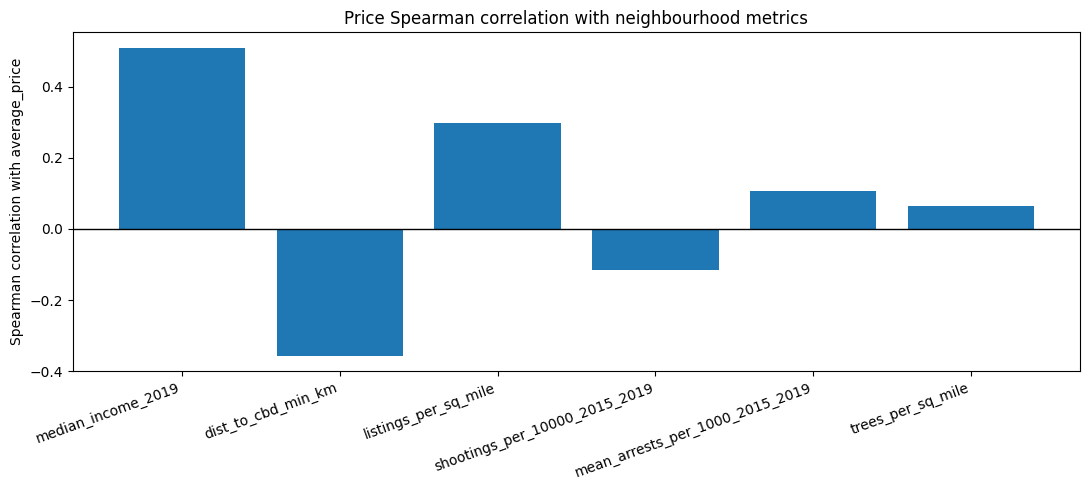

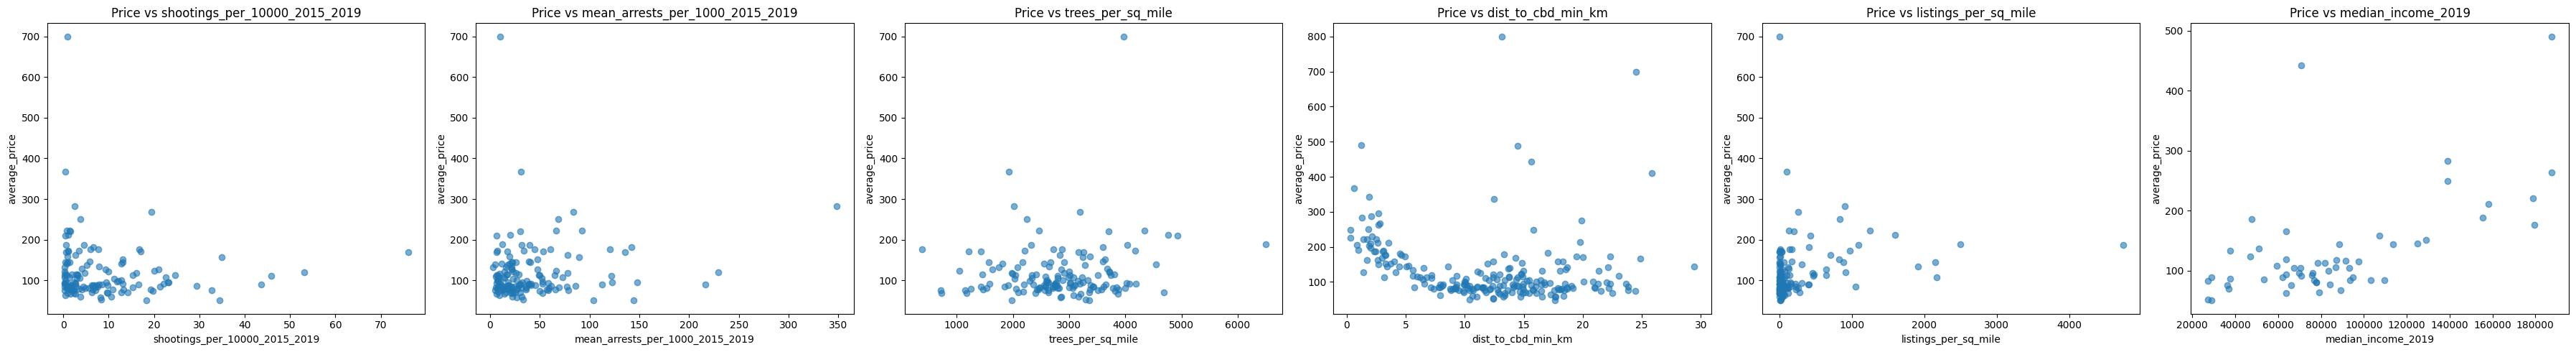

In [94]:
# Combined correlation view: listing-level + neighbourhood-level
 # 1) Listing-level: price vs distance to CBD
listing_level_df = airbnb_nyc_df[['price', 'dist_to_cbd_min_km']].copy()
listing_level_df['price'] = pd.to_numeric(listing_level_df['price'], errors='coerce')
listing_level_df['dist_to_cbd_min_km'] = pd.to_numeric(listing_level_df['dist_to_cbd_min_km'], errors='coerce')
listing_level_df = listing_level_df.dropna().copy()

listing_cbd_corr_summary = pd.DataFrame([
    {
        'variable': 'dist_to_cbd_min_km (listing-level)',
        'spearman_corr_with_price': listing_level_df['price'].corr(listing_level_df['dist_to_cbd_min_km'], method='spearman'),
        'rows_used': len(listing_level_df),
    }
])

print('Listing-level Spearman correlation: price vs dist_to_cbd_min_km')
display(listing_cbd_corr_summary)

# 2) Neighbourhood-level: raw average price vs neighbourhood metrics
# Add listing density: listings_per_sq_mile.
listing_density_df = (
    airbnb_nyc_df[['neighbourhood']]
    .dropna(subset=['neighbourhood'])
    .copy()
)
listing_density_df['neighbourhood'] = listing_density_df['neighbourhood'].apply(clean_neighbourhood_keep_coop)
listing_density_df = (
    listing_density_df
    .groupby('neighbourhood', as_index=False)
    .size()
    .rename(columns={'size': 'listing_count'})
)

listing_density_df = listing_density_df.merge(
    neighborhood_area_df[['neighbourhood', 'area_sq_miles']],
    on='neighbourhood',
    how='inner',
)
listing_density_df = listing_density_df[listing_density_df['area_sq_miles'] > 0].copy()
listing_density_df['listings_per_sq_mile'] = (
    listing_density_df['listing_count'] / listing_density_df['area_sq_miles']
)

corr_source = neighbourhood_combined_metrics.merge(
    cbd_distance_by_neighbourhood,
    on='neighbourhood',
    how='left',
).merge(
    listing_density_df[['neighbourhood', 'listings_per_sq_mile']],
    on='neighbourhood',
    how='left',
).merge(
    median_income_by_neighbourhood,
    on='neighbourhood',
    how='left',
)

corr_cols = [
    'average_price',
    'shootings_per_10000_2015_2019',
    'mean_arrests_per_1000_2015_2019',
    'trees_per_sq_mile',
    'dist_to_cbd_min_km',
    'listings_per_sq_mile',
    'median_income_2019',
]

corr_df = corr_source[corr_cols].copy()
corr_df = corr_df.apply(pd.to_numeric, errors='coerce')

# Spearman correlations with average price
target = 'average_price'
feature_cols = [c for c in corr_cols if c != target]

corr_summary = pd.DataFrame({
    'variable': feature_cols,
    'spearman_corr_with_price': [corr_df[target].corr(corr_df[c], method='spearman') for c in feature_cols],
})

corr_summary = corr_summary.sort_values('spearman_corr_with_price', key=lambda s: s.abs(), ascending=False).reset_index(drop=True)

print('Spearman correlation with average_price (neighbourhood level):')
display(corr_summary)

# Bar chart of Spearman correlations
plt.figure(figsize=(11, 5))
plt.bar(corr_summary['variable'], corr_summary['spearman_corr_with_price'])
plt.axhline(0, color='black', linewidth=1)
plt.xticks(rotation=20, ha='right')
plt.ylabel('Spearman correlation with average_price')
plt.title('Price Spearman correlation with neighbourhood metrics')
plt.tight_layout()
plt.show()

# Scatter plots for each variable against price
fig, axes = plt.subplots(1, len(feature_cols), figsize=(36, 5))
if len(feature_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, feature_cols):
    plot_df = corr_df[[target, col]].dropna()
    ax.scatter(plot_df[col], plot_df[target], alpha=0.6)
    ax.set_xlabel(col)
    ax.set_ylabel(target)
    ax.set_title(f'Price vs {col}')

plt.tight_layout()
plt.show()

### 3) Integrated Table Profiling and Data Coverage Check

Before deeper comparisons, we profile the merged neighbourhood-level analysis table to inspect coverage and missingness for each derived metric.

In [96]:
analysis_cols = [
    'neighbourhood',
    'average_price',
    'shootings_per_10000_2015_2019',
    'mean_arrests_per_1000_2015_2019',
    'trees_per_sq_mile',
    'dist_to_cbd_min_km',
    'listings_per_sq_mile',
    'median_income_2019',
]

analysis_table = corr_source[analysis_cols].copy()

missing_profile = (
    analysis_table
    .isna()
    .sum()
    .to_frame('missing_count')
    .assign(missing_pct=lambda d: (d['missing_count'] / len(analysis_table) * 100).round(2))
    .sort_values('missing_count', ascending=False)
)

print('Missing-value profile for integrated neighbourhood analysis table:')
display(missing_profile)

print('Summary statistics for numeric variables used in analysis:')
display(
    analysis_table
    .drop(columns=['neighbourhood'])
    .apply(pd.to_numeric, errors='coerce')
    .describe()
    .T
)

print(f"Total neighbourhood rows in integrated table: {len(analysis_table)}")

Missing-value profile for integrated neighbourhood analysis table:


,missing_count,missing_pct
median_income_2019,163,74.09
shootings_per_10000_2015_2019,84,38.18
trees_per_sq_mile,75,34.09
mean_arrests_per_1000_2015_2019,75,34.09
listings_per_sq_mile,75,34.09
average_price,0,0.00
neighbourhood,0,0.00
dist_to_cbd_min_km,0,0.00


Summary statistics for numeric variables used in analysis:


,count,mean,std,min,25%,50%,75%,max
average_price,220.0,133.343373,94.721695,47.333333,81.598077,101.314474,153.223214,800.000000
shootings_per_10000_2015_2019,136.0,8.713819,11.406169,0.247614,1.333936,4.451915,12.253441,76.013112
mean_arrests_per_1000_2015_2019,145.0,41.509872,46.247478,3.080318,14.507579,26.481238,52.382043,348.250087
trees_per_sq_mile,145.0,2828.209544,907.530699,381.872042,2324.770948,2801.600179,3365.722310,6492.566472
dist_to_cbd_min_km,220.0,11.931923,6.396123,0.329212,7.149671,12.398754,16.441948,29.431199
listings_per_sq_mile,145.0,246.616552,575.933898,0.429131,11.182004,44.546233,160.845287,4740.312929
median_income_2019,57.0,85611.428454,40828.831517,27324.753710,63588.365630,77790.755090,97535.653370,187634.991600


Total neighbourhood rows in integrated table: 220


From this profiling, we can verify whether the integrated table is sufficiently complete for comparative analysis. Variables with higher missingness should be interpreted with caution in downstream conclusions.

### 4) Borough-Level Contextual Comparison

To add interpretive context, we map each neighbourhood to its dominant borough (based on Airbnb listings) and compare borough-level price and feature aggregates.

Borough-level contextual summary (means over mapped neighbourhoods):


,borough,neighbourhoods,avg_price,avg_shootings_per_10000,avg_arrests_per_1000,avg_trees_per_sq_mile,avg_median_income
2,Manhattan,32,212.277558,11.342467,76.996118,3325.105331,123369.860720
4,Staten Island,42,143.908728,5.708164,26.847976,2273.462896,102366.634337
1,Brooklyn,47,137.685040,9.911317,42.798914,2916.772501,82390.650642
3,Queens,51,108.577211,5.357547,27.214519,2795.132133,87063.658773
0,Bronx,48,93.538726,11.750489,47.374646,2846.665977,49679.230601


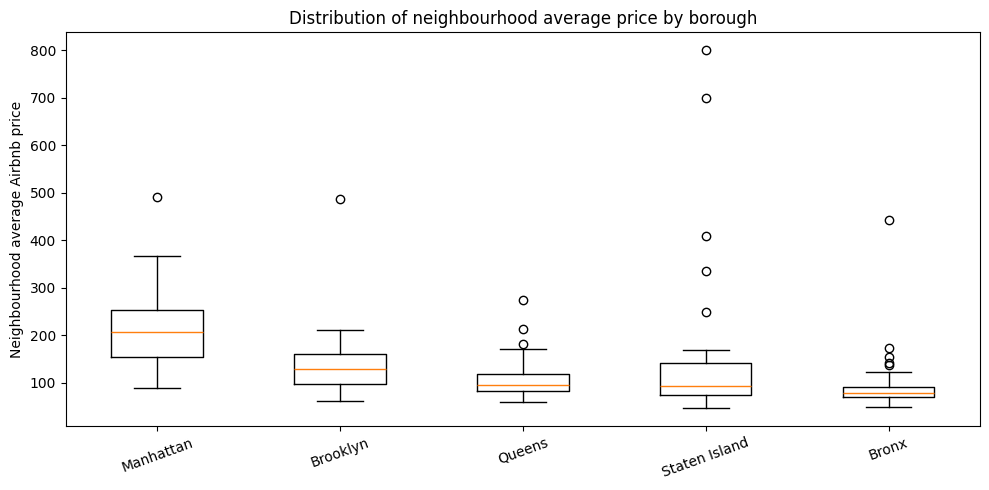

In [97]:
# Build neighbourhood-to-borough lookup using the most frequent borough per neighbourhood.
hood_borough_map = (
    airbnb_nyc_df[['neighbourhood', 'neighbourhood_group']]
    .dropna(subset=['neighbourhood', 'neighbourhood_group'])
    .copy()
)
hood_borough_map['neighbourhood'] = hood_borough_map['neighbourhood'].apply(clean_neighbourhood_keep_coop)
hood_borough_map = (
    hood_borough_map
    .groupby('neighbourhood')['neighbourhood_group']
    .agg(lambda s: s.mode().iat[0] if not s.mode().empty else s.iloc[0])
    .reset_index()
    .rename(columns={'neighbourhood_group': 'borough'})
)

borough_analysis = analysis_table.merge(hood_borough_map, on='neighbourhood', how='left')

borough_summary = (
    borough_analysis
    .groupby('borough', as_index=False)
    .agg(
        neighbourhoods=('neighbourhood', 'nunique'),
        avg_price=('average_price', 'mean'),
        avg_shootings_per_10000=('shootings_per_10000_2015_2019', 'mean'),
        avg_arrests_per_1000=('mean_arrests_per_1000_2015_2019', 'mean'),
        avg_trees_per_sq_mile=('trees_per_sq_mile', 'mean'),
        avg_median_income=('median_income_2019', 'mean')
    )
    .sort_values('avg_price', ascending=False)
)

print('Borough-level contextual summary (means over mapped neighbourhoods):')
display(borough_summary)

# Price distribution by borough (neighbourhood-level average price).
plot_df = borough_analysis[['borough', 'average_price']].dropna()
borough_order = plot_df.groupby('borough')['average_price'].median().sort_values(ascending=False).index.tolist()
groups = [plot_df.loc[plot_df['borough'] == b, 'average_price'].values for b in borough_order]

plt.figure(figsize=(10, 5))
plt.boxplot(groups, tick_labels=borough_order)
plt.ylabel('Neighbourhood average Airbnb price')
plt.title('Distribution of neighbourhood average price by borough')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### 5) Composite Neighbourhood Signal and Ranking

Finally, we build a simple composite index by standardizing key indicators and combining favorable (+) and unfavorable (-) signals. This provides an interpretable ranking view to complement pairwise correlations.

Top 10 neighbourhoods by composite signal score:


,neighbourhood,average_price,composite_signal_score
43,Upper West Side,210.918316,1.450034
28,Murray Hill,220.958763,1.335648
18,Fort Greene,151.374233,0.723153
22,Jackson Heights,80.897849,0.592491
9,Chelsea,249.738544,0.588567
32,Rego Park,83.877358,0.582800
33,Ridgewood,77.184397,0.533616
0,Astoria,117.187778,0.479249
1,Bay Ridge,144.432624,0.434217
5,Borough Park,63.066176,0.407302


Bottom 10 neighbourhoods by composite signal score:


,neighbourhood,average_price,composite_signal_score
27,Mott Haven,88.916667,-1.378870
19,Harlem,118.974041,-0.987866
11,Coney Island,123.705882,-0.940775
21,Hunts Point,50.500000,-0.872135
40,Tremont,51.545455,-0.754103
23,Jamaica,95.770563,-0.727069
6,Brownsville,76.459016,-0.665650
14,East New York,85.426606,-0.631281
39,Tottenville,144.857143,-0.483227
45,Williamsbridge,96.750000,-0.350422


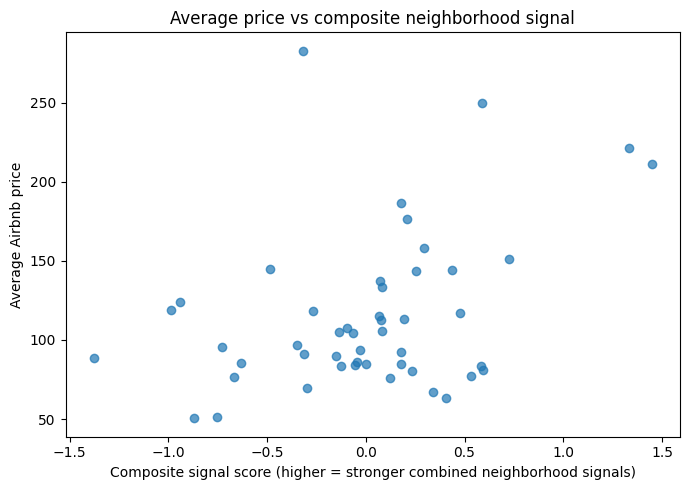

Spearman correlation: average_price vs composite_signal_score
0.2254667824576639


In [98]:
rank_df = analysis_table[[
    'neighbourhood',
    'average_price',
    'shootings_per_10000_2015_2019',
    'mean_arrests_per_1000_2015_2019',
    'trees_per_sq_mile',
    'dist_to_cbd_min_km',
    'median_income_2019',
]].copy()

rank_df = rank_df.dropna().reset_index(drop=True)

# Z-score utility with safe handling.
def zscore_series(s):
    s = pd.to_numeric(s, errors='coerce')
    std = s.std(ddof=0)
    if pd.isna(std) or std == 0:
        return pd.Series(np.zeros(len(s)), index=s.index)
    return (s - s.mean()) / std

rank_df['income_z'] = zscore_series(rank_df['median_income_2019'])
rank_df['greenery_z'] = zscore_series(rank_df['trees_per_sq_mile'])
rank_df['access_z'] = -zscore_series(rank_df['dist_to_cbd_min_km'])
rank_df['safety_shoot_z'] = -zscore_series(rank_df['shootings_per_10000_2015_2019'])
rank_df['safety_arrest_z'] = -zscore_series(rank_df['mean_arrests_per_1000_2015_2019'])

rank_df['composite_signal_score'] = rank_df[
    ['income_z', 'greenery_z', 'access_z', 'safety_shoot_z', 'safety_arrest_z']
].mean(axis=1)

top_signal = rank_df.sort_values('composite_signal_score', ascending=False).head(10)
bottom_signal = rank_df.sort_values('composite_signal_score', ascending=True).head(10)

print('Top 10 neighbourhoods by composite signal score:')
display(top_signal[['neighbourhood', 'average_price', 'composite_signal_score']])

print('Bottom 10 neighbourhoods by composite signal score:')
display(bottom_signal[['neighbourhood', 'average_price', 'composite_signal_score']])

# Relationship between composite signal and average price.
plt.figure(figsize=(7, 5))
plt.scatter(rank_df['composite_signal_score'], rank_df['average_price'], alpha=0.7)
plt.xlabel('Composite signal score (higher = stronger combined neighborhood signals)')
plt.ylabel('Average Airbnb price')
plt.title('Average price vs composite neighborhood signal')
plt.tight_layout()
plt.show()

print('Spearman correlation: average_price vs composite_signal_score')
print(rank_df['average_price'].corr(rank_df['composite_signal_score'], method='spearman'))

### Analytical Summary

Overall, this analysis combines univariate profiling, rank-based correlation, borough context, and a multi-indicator composite view. Together, these outputs provide a coherent basis for discussing which neighbourhood conditions appear most aligned with Airbnb pricing patterns and where potential confounding or missing-data limits remain.